# 35 - Loss Functions

**Section:** Metaparameters | **Prereqs:** `Metaparameters/ReLU_Varients.ipynb` | **Next:** `Metaparameters/BatchNorm.ipynb`

The loss defines what 'wrong' means. Everything else - the optimizer, the
architecture - only serves it. This notebook plots each loss as a function of the
prediction, which is the fastest way to understand what it rewards.

**The decision table**

| Task | Model output | Loss |
|---|---|---|
| Regression | 1 unbounded number | `MSELoss` (or `L1Loss` if outliers matter) |
| Binary classification | 1 raw logit | `BCEWithLogitsLoss` |
| Binary, output already a probability | 1 value in (0,1) | `BCELoss` |
| Multiclass | C raw logits | `CrossEntropyLoss` |
| Multiclass, output is log_softmax | C log-probs | `NLLLoss` |

**The shapes matter.** MSE is a parabola: symmetric, gentle near the answer.
BCE is asymmetric and goes to infinity as you confidently predict the wrong
class - which is exactly the behaviour you want from a classifier, and why MSE on
a classification task trains badly.

**`BCEWithLogitsLoss` over `Sigmoid` + `BCELoss`,** always. It fuses the two and
uses the log-sum-exp trick, so a saturated sigmoid produces a finite gradient
instead of `inf` or `nan`.

**Custom losses** are just `nn.Module`s with a `forward` that returns a scalar.
Anything built from differentiable torch ops will backpropagate.

In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

In [175]:
# MSE loss as the prediction sweeps past the true value 0.5.
lossMSE = nn.MSELoss()

yhat = torch.linspace(-2,2,101)
y = torch.tensor(0.5)


losses = []

for i in yhat:
  losses.append( (lossMSE(i,y)).item() )

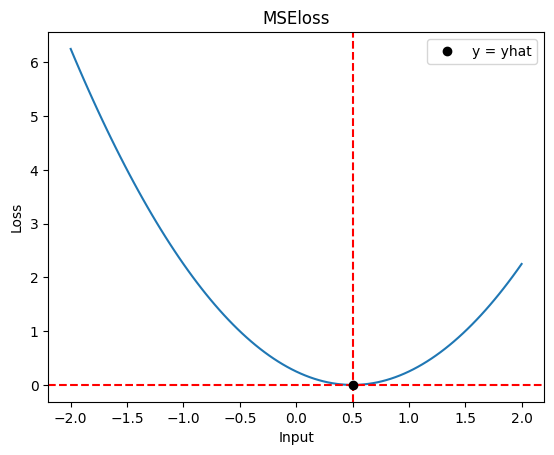

In [176]:
# The parabola. Symmetric, zero at yhat = y, and flat near the minimum -
# which means small errors produce small gradients, so the last bit of fitting
# is slow.
plt.plot(yhat,losses);
plt.xlabel('Input')
plt.ylabel('Loss')
plt.title("MSEloss")
plt.axvline(y,color='r', linestyle='--')
plt.axhline(0,color='r', linestyle='--')
plt.plot(0.5,0,"ko",label="y = yhat")
plt.legend();

In [177]:
# BCE loss for both possible labels, over predictions in (0,1).
# Note the range starts at 0.0001, not 0: BCE is -log(p), which is infinite at
# exactly 0 or 1. Real implementations clamp for this reason.
lossBCE = nn.BCELoss()

yhat = torch.linspace(.0001,.9999,101, dtype=torch.float)
y1 = torch.tensor(0,dtype=torch.float)
y2 = torch.tensor(1,dtype=torch.float)



losses = torch.zeros((101,2))

for i in range(101):
  losses[i,0] = lossBCE(yhat[i],y1)
  losses[i,1] = lossBCE(yhat[i],y2)

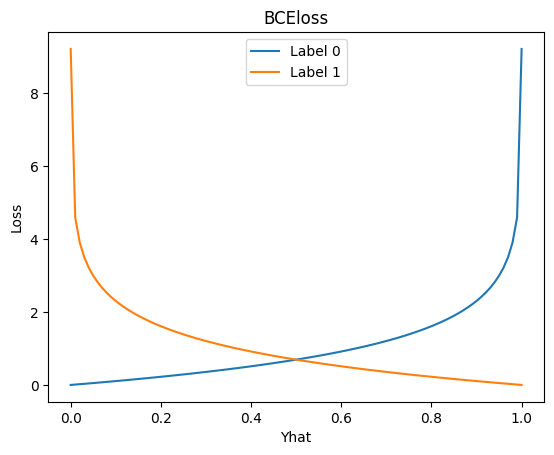

In [178]:
# Two mirrored curves. Each rises without bound as the prediction moves towards
# the WRONG label. Confident and wrong is punished far harder than uncertain -
# the property MSE lacks, and the reason classifiers use cross-entropy.
plt.plot(yhat,losses,label=['Label 0','Label 1'])
plt.ylabel("Loss")
plt.xlabel("Yhat")
plt.title("BCEloss")
# plt.yscale('log')
plt.legend();

In [179]:
# The same loss taking raw logits instead of probabilities.
lossBCEwithlogits = nn.BCEWithLogitsLoss()

yhat = torch.linspace(-2,2,101, dtype=torch.float)
y1 = torch.tensor(0,dtype=torch.float)
y2 = torch.tensor(1,dtype=torch.float)



losses = torch.zeros((101,2))

for i in range(101):
  losses[i,0] = lossBCEwithlogits(yhat[i],y1)
  losses[i,1] = lossBCEwithlogits(yhat[i],y2)

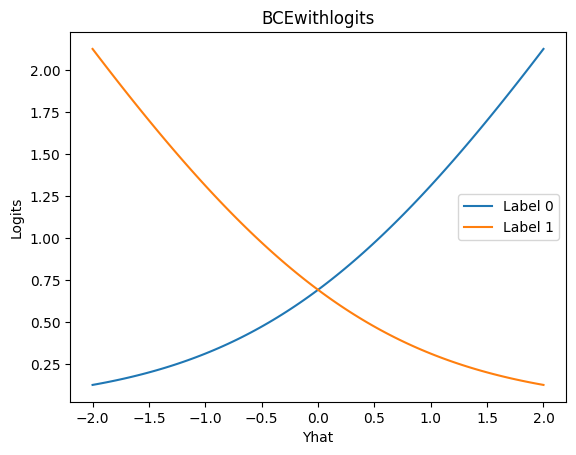

In [180]:
# The same shape, now over the logit axis, and finite at every input - no
# clamping needed. This is why BCEWithLogitsLoss is the safe default.
plt.plot(yhat,losses,label=['Label 0','Label 1'])
plt.ylabel("Loss")
plt.xlabel("Yhat (logit)")
plt.title("BCEwithlogits")
# plt.yscale('log')
plt.legend();

## BCEloss Vs BCEwithlogitloss

In [181]:
# Proof the two are the same function: BCE(sigmoid(x), y) == BCEWithLogits(x, y).
# Only the numerical stability differs.
x = torch.tensor(2.0)
x_sigmoid = torch.sigmoid(x)
yhat = torch.tensor(0.5)

loss1 = lossBCE(x_sigmoid, yhat)
loss2 = lossBCEwithlogits(x, yhat)

In [182]:
# The two values agree to floating-point precision.
loss1, loss2

(tensor(1.1269), tensor(1.1269))

## Cross Entropy loss

In [183]:
# CrossEntropyLoss on RAW SCORES [1,4,3]. The loss is lowest when the correct
# class is the one with the largest score (index 1 here).
probs = torch.tensor([1,4,3],dtype=torch.float)

lossfunc = nn.CrossEntropyLoss()
losses = []

for i in range(3):
  correctVal = torch.tensor(i)
  loss = lossfunc(probs,correctVal)
  print(f'Loss = {loss}, correct Val {correctVal}')

Loss = 3.3490121364593506, correct Val 0
Loss = 0.349012166261673, correct Val 1
Loss = 1.3490121364593506, correct Val 2


In [184]:
# The classic bug, demonstrated: applying softmax before CrossEntropyLoss.
# The loss still runs and still ranks the classes correctly, but the values are
# compressed and the gradients are much weaker - the model trains slowly for no
# visible reason. Feed CrossEntropyLoss raw logits.
sm = nn.Softmax(dim=0)
probs_SM = sm(probs)

for i in range(3):
  correctVal = torch.tensor(i)
  loss = lossfunc(probs_SM,correctVal)
  print(f'Loss = {loss}, correct Val {correctVal}')

# This is wrong as the CrossEntropyLoss already computes softmax. this case is double softmaxed

Loss = 1.436583399772644, correct Val 0
Loss = 0.7663178443908691, correct Val 1
Loss = 1.2122058868408203, correct Val 2


In [185]:
# log_softmax: the form NLLLoss expects. CrossEntropyLoss = LogSoftmax + NLLLoss.
logSM = nn.LogSoftmax(dim=0)
probs_LSM = logSM(probs)

In [186]:
# The three representations side by side: raw logits (any real number),
# probabilities (sum to 1), log-probabilities (all <= 0).
# Same information, three scales - knowing which one a function wants is most of
# what goes wrong in PyTorch classification code.
print(probs)
print(probs_SM)
print(probs_LSM)

tensor([1., 4., 3.])
tensor([0.0351, 0.7054, 0.2595])
tensor([-3.3490, -0.3490, -1.3490])


# Making you own loss func

In [187]:
# A custom loss: subclass nn.Module, implement forward, return a scalar.
# This one is mean absolute error (nn.L1Loss already exists).
# The .mean() is not optional: backward() needs a SCALAR, and returning the
# per-element tensor raises 'grad can be implicitly created only for scalar
# outputs'.
class NewLoss(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self,x,y):

   return torch.mean(torch.abs(x-y))

In [188]:
# Using it: one scalar out, ready for backward().
newLossFunc = NewLoss()
a = torch.tensor(5)
b = torch.tensor(3)

loss = newLossFunc(b,a)
loss

tensor(2)

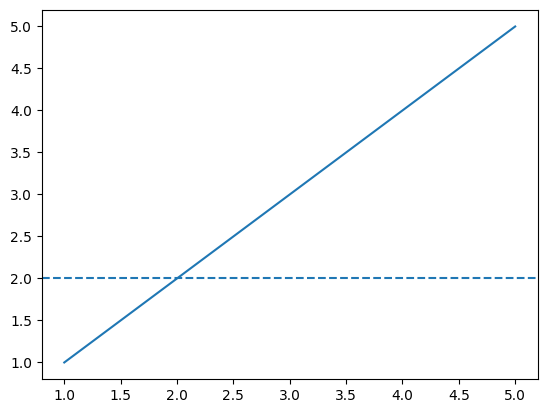

In [189]:
plt.plot([1,2,3,4,5],[1,2,3,4,5])
plt.axhline(2,linestyle="--");